In [378]:
from datetime import datetime
import MetaTrader5 as mt5
import pandas as pd
import pytz
import time
import pandas_ta as pta
import matplotlib.pyplot as plt 
import threading

# import threading
mt5.initialize()


True

In [370]:
def price_action(symbol, lot, ask, bid, order_type):
    buy_profit=mt5.order_calc_profit(order_type,symbol,lot,ask,bid)
    return buy_profit
price_action("EURUSD", 0.02, 1.18969, 1.17030,mt5.ORDER_TYPE_SELL)

38.78

In [365]:
def get_values(symbol):
    timezone = pytz.timezone("Etc/UTC")
    x = datetime.now()
    utc_from = datetime(x.year, x.month, 10, tzinfo=timezone)
    utc_to = datetime(x.year, x.month, x.day+1, tzinfo=timezone)
    rates = mt5.copy_rates_range(symbol, mt5.TIMEFRAME_M15, utc_from, utc_to)

    rates_frame = pd.DataFrame(rates)
#     rates_frame = rates_frame.iloc[-150:]
    rates_frame = rates_frame.drop(['tick_volume', 'spread', 'real_volume'], axis=1)
    # convert time in seconds into the datetime format
    rates_frame['clsma']= rates_frame['close'].rolling(window=8).mean()
    rates_frame['smaC']= rates_frame['clsma'].rolling(window=8).mean()


    rates_frame['clsma']= rates_frame['open'].rolling(window=8).mean()
    rates_frame['smaO']= rates_frame['clsma'].rolling(window=8).mean()

    rates_frame['time']=pd.to_datetime(rates_frame['time'], unit='s')
    rates_frame = rates_frame.set_index('time')
    rates_frame = rates_frame.drop(['high', 'low', 'clsma'], axis=1)
    return rates_frame

In [366]:
global global_loss
global profit
global conti


profit = []

global_loss = []
symbol = "EURGBP"
b = get_values(symbol)
b = b.dropna()
b

,open,close,smaC,smaO
time,,,,
2021-08-10 03:30:00,0.84750,0.84750,0.847463,0.847417
2021-08-10 03:45:00,0.84750,0.84738,0.847487,0.847449
2021-08-10 04:00:00,0.84738,0.84743,0.847502,0.847477
2021-08-10 04:15:00,0.84743,0.84751,0.847510,0.847493
2021-08-10 04:30:00,0.84754,0.84764,0.847516,0.847504
...,...,...,...,...
2021-08-20 11:30:00,0.85693,0.85682,0.857575,0.857563
2021-08-20 11:45:00,0.85684,0.85697,0.857562,0.857577
2021-08-20 12:00:00,0.85696,0.85751,0.857548,0.857564


In [351]:
global global_loss
global profit
global conti


profit = []

global_loss = []
symbol = "EURGBP"
a= get_values(symbol)
a = a.dropna()
a

,open,close,smaC,smaO
time,,,,
2021-08-10 01:10:00,0.84740,0.84745,0.847213,0.847204
2021-08-10 01:15:00,0.84746,0.84756,0.847226,0.847208
2021-08-10 01:20:00,0.84755,0.84749,0.847242,0.847221
2021-08-10 01:25:00,0.84748,0.84746,0.847265,0.847239
2021-08-10 01:30:00,0.84745,0.84747,0.847293,0.847261
...,...,...,...,...
2021-08-20 11:40:00,0.85696,0.85682,0.857418,0.857490
2021-08-20 11:45:00,0.85684,0.85693,0.857339,0.857418
2021-08-20 11:50:00,0.85693,0.85684,0.857257,0.857340


In [376]:
for i in range(len(b)):
    for j in range(len(a)):
        if a.iloc[j].name < b.iloc[i].name:
            print(a.iloc[j].name)
            print(b.iloc[i].name)
            a.iloc[j].smaC = b.iloc[i].smaC
            a.iloc[j].smaO = b.iloc[i].smaO
    break

2021-08-10 01:10:00
2021-08-10 03:30:00
2021-08-10 01:15:00
2021-08-10 03:30:00
2021-08-10 01:20:00
2021-08-10 03:30:00
2021-08-10 01:25:00
2021-08-10 03:30:00
2021-08-10 01:30:00
2021-08-10 03:30:00
2021-08-10 01:35:00
2021-08-10 03:30:00
2021-08-10 01:40:00
2021-08-10 03:30:00
2021-08-10 01:45:00
2021-08-10 03:30:00
2021-08-10 01:50:00
2021-08-10 03:30:00
2021-08-10 01:55:00
2021-08-10 03:30:00
2021-08-10 02:00:00
2021-08-10 03:30:00
2021-08-10 02:05:00
2021-08-10 03:30:00
2021-08-10 02:10:00
2021-08-10 03:30:00
2021-08-10 02:15:00
2021-08-10 03:30:00
2021-08-10 02:20:00
2021-08-10 03:30:00
2021-08-10 02:25:00
2021-08-10 03:30:00
2021-08-10 02:30:00
2021-08-10 03:30:00
2021-08-10 02:35:00
2021-08-10 03:30:00
2021-08-10 02:40:00
2021-08-10 03:30:00
2021-08-10 02:45:00
2021-08-10 03:30:00
2021-08-10 02:50:00
2021-08-10 03:30:00
2021-08-10 02:55:00
2021-08-10 03:30:00
2021-08-10 03:00:00
2021-08-10 03:30:00
2021-08-10 03:05:00
2021-08-10 03:30:00
2021-08-10 03:10:00
2021-08-10 03:30:00


In [377]:
a

,open,close,smaC,smaO
time,,,,
2021-08-10 01:10:00,0.84740,0.84745,0.847463,0.847417
2021-08-10 01:15:00,0.84746,0.84756,0.847463,0.847417
2021-08-10 01:20:00,0.84755,0.84749,0.847463,0.847417
2021-08-10 01:25:00,0.84748,0.84746,0.847463,0.847417
2021-08-10 01:30:00,0.84745,0.84747,0.847463,0.847417
...,...,...,...,...
2021-08-20 11:40:00,0.85696,0.85682,0.857418,0.857490
2021-08-20 11:45:00,0.85684,0.85693,0.857339,0.857418
2021-08-20 11:50:00,0.85693,0.85684,0.857257,0.857340


In [345]:
def follow(j, a, buy_price, order_type):
    loss = 0.0
    g = 0
    for k in range(j+1, len(a)):
        sell_price = a.iloc[k].close
        pp = price_action(symbol, 0.02, buy_price, sell_price, order_type)
        if pp > 0.0:
            profit.append(pp)
            global_loss.append(loss)
            break
        elif pp < 0.0:
            if pp < loss:
                loss = pp
    if k == len(a)-1:
        conti.append([pp, a.iloc[j-1].name])
        
        
            
    

In [349]:
#less negatives more positives
# symbol = "CADJPY"
# b= get_values1(symbol)
# b = b.dropna()
b = a
B = []
check = 0
profit = []
index = []
indexB = []
counter = 0
peck = 0
p= []
checks = 0
counterr = 0
profits = []
up = 0
rsi1 = []
rsi2 = []
mul = 100000
global_loss = []
conti = []

for i in range(2,len(a)-1):
    if a.iloc[i-1].smaC < a.iloc[i-1].smaO and check == 0:
        buy_price = b.iloc[i].open #BUY Action
        p2 = threading.Thread(target=follow, args=(i, a, buy_price, mt5.ORDER_TYPE_SELL))
        p2.start()
        print("#"*20)
        print("SELL")
        print(round(a.iloc[i-2].smaC, 6), round(a.iloc[i-2].smaO, 6), a.iloc[i-2].name)
        print(round(a.iloc[i-1].smaC, 6), round(a.iloc[i-1].smaO, 6), a.iloc[i-1].name)
        if (round(a.iloc[i-1].smaC, 6) - round(a.iloc[i-1].smaO, 6)) <  :
        
        print(round(a.iloc[i+1].smaC, 6), round(a.iloc[i+1].smaO, 6), a.iloc[i+1].name)
        
        
        
        print(a.iloc[i].name)
        print(a.iloc[i].open)
        print("*"*20)
        check = 1
        checks = 0
    elif a.iloc[i-1].smaC > a.iloc[i-1].smaO and checks == 0:
        buy_price = b.iloc[i].open #BUY Action
        p3 = threading.Thread(target=follow, args=(i, a, buy_price,mt5.ORDER_TYPE_BUY))
        p3.start()
        print("#"*20)
        print("BUY")
        print(round(a.iloc[i-1].smaC, 6), round(a.iloc[i-1].smaO, 6), a.iloc[i-1].name)
        print(a.iloc[i].name)
        print(a.iloc[i].open)
        print("*"*20)
        checks = 1
        check = 0

####################
BUY
0.847487 0.847449 2021-08-10 03:45:00
2021-08-10 04:00:00
0.84738
********************
####################
SELL
0.847749 0.847744 2021-08-10 07:30:00
0.847748 0.847753 2021-08-10 07:45:00
0.847739 0.847752 2021-08-10 08:00:00
0.847729 0.847742 2021-08-10 08:15:00
2021-08-10 08:00:00
0.8478
********************
####################
BUY
0.847714 0.847708 2021-08-10 09:15:00
2021-08-10 09:30:00
0.84792
********************
####################
SELL
0.847727 0.847726 2021-08-10 10:00:00
0.847714 0.847727 2021-08-10 10:15:00
0.84768 0.847714 2021-08-10 10:30:00
0.847635 0.847681 2021-08-10 10:45:00
2021-08-10 10:30:00
0.84704
********************
####################
BUY
0.845819 0.845813 2021-08-10 16:15:00
2021-08-10 16:30:00
0.84642
********************
####################
SELL
0.846929 0.846926 2021-08-10 21:45:00
0.846929 0.846929 2021-08-10 22:00:00
0.846929 0.846929 2021-08-10 22:15:00
0.846927 0.846928 2021-08-10 22:30:00
2021-08-10 22:15:00
0.84695
******

In [329]:
sum(profit)

21.969999999999995

In [330]:
sum(global_loss)

-31.22

In [331]:
conti

[[-31.88, Timestamp('2021-08-12 10:45:00')],
 [-19.37, Timestamp('2021-08-17 00:30:00')],
 [-18.55, Timestamp('2021-08-19 07:00:00')]]

In [317]:
sum(conti)

-69.8

In [190]:
len(indexB)

46

In [ ]:
n = 0
p = 0
tn = 0
tp = 0

for i in profit:
    if i<0.0:
        n = n+i
        tn = tn+1
    else:
        p = p+i
        tp = tp+1
print(f"Total negative sm -->{n}")
print(f"Total negative -->{tn}")      
print(f"Total positive sm -->{p}")      
print(f"Total positive -->{tp}") 
print(f"Length {len(profit)}")

(array([18844., 18846., 18848., 18850., 18852., 18854., 18856., 18858.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

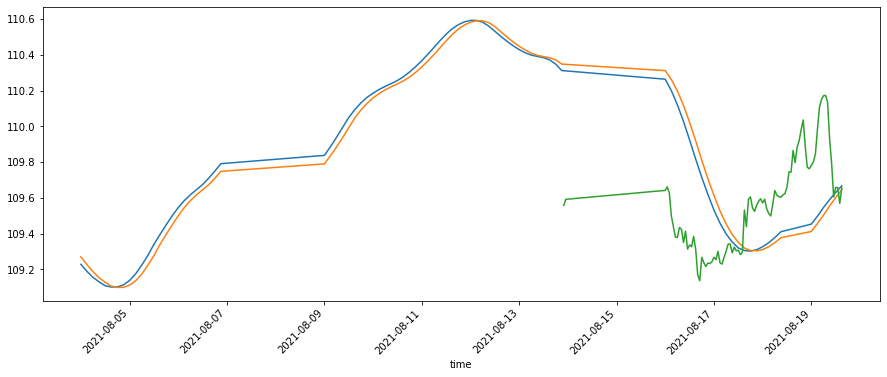

In [35]:
# plt.plot(a[-10:].smaC)
# plt.plot(a[-10:].smaO)
a['smaC'][-90:].plot(figsize=(15,6))
# rates_frame['ll'] = rates_frame['close'].rolling(window=100).mean()
a['smaO'][-90:].plot()
b['close'][-90:].plot()

# plt.plot( l[200:-100], 'r').rolling(window=100).

plt.xticks(rotation = 45)

In [ ]:
  elif check == 1:
        sell_price = a.iloc[i].close
        pp = price_action(symbol, 0.02, buy_price, sell_price,mt5.ORDER_TYPE_SELL)
        print(f"{pp}-----{a.iloc[i].close}--{a.iloc[i].name}")


        if pp > 0.0:
            check = 0
            profit.append(pp)
            index.append(pp)
            print("Greater")
        elif a.iloc[i].smaC < a.iloc[i].smaO:
            check = 0
            profit.append(pp)
            if pp > 0.0:
                index.append(pp)
            else:
                indexB.append(pp)
            print("smaC<smaO")
        elif a.iloc[i].smaC > a.iloc[i].smaO:
            check = 0
            profit.append(pp)
            if pp > 0.0:
                index.append(pp)
            else:
                indexB.append(pp)
            print("smaC>smaO")
#         i = i-2
#         print(i)

# pd.date_range(end = datetime.today(), periods = 100).to_pydatetime().tolist()

#OR

pd.date_range(start="2021-08-10",end="2021-08-11", freq=).to_pydatetime().tolist()
# a.iloc[0].name

In [356]:
print(a.iloc[0].name)

2021-08-10 01:10:00


In [363]:
pd.date_range?

In [362]:
pd.date_range(start="2021-08-10",end="2021-08-11", freq=5).to_pydatetime().tolist()

ValueError: Invalid frequency: 5

In [364]:
pd.timedelta_range?

In [420]:
def Action(symbol, lot, signal):
    try:
        symbol_info = mt5.symbol_info(symbol)

        a = [[mt5.ORDER_TYPE_SELL, mt5.symbol_info_tick(symbol).bid], [mt5.ORDER_TYPE_BUY, mt5.symbol_info_tick(symbol).ask]]
        price = a[signal][1]
        deviation = 200
        
        request = {
            "action": mt5.TRADE_ACTION_DEAL,
            "symbol": symbol,
            "volume": lot,
            "type": a[signal][0],
            "price": price,
            "deviation": deviation,
            "magic": 234000,
            "comment": "python script open",
            "type_time": mt5.ORDER_TIME_GTC,
            "type_filling": mt5.ORDER_FILLING_RETURN,
        }
        result = mt5.order_send(request)
        return result
    except Exception as e:
        print("Action")
        print(e)

In [421]:
r = Action("USDJPY", 0.02, 1)

In [422]:
print(r)

OrderSendResult(retcode=10009, deal=1076052854, order=1092979311, volume=0.02, price=109.629, bid=109.629, ask=109.629, comment='Request executed', request_id=949, retcode_external=0, request=TradeRequest(action=1, magic=234000, order=0, symbol='USDJPY', volume=0.02, price=109.629, stoplimit=0.0, sl=0.0, tp=0.0, deviation=200, type=0, type_filling=2, type_time=0, expiration=0, comment='python script open', position=0, position_by=0))


In [423]:
r.price

109.629

In [387]:
dir(mt5)

['ACCOUNT_MARGIN_MODE_EXCHANGE',
 'ACCOUNT_MARGIN_MODE_RETAIL_HEDGING',
 'ACCOUNT_MARGIN_MODE_RETAIL_NETTING',
 'ACCOUNT_STOPOUT_MODE_MONEY',
 'ACCOUNT_STOPOUT_MODE_PERCENT',
 'ACCOUNT_TRADE_MODE_CONTEST',
 'ACCOUNT_TRADE_MODE_DEMO',
 'ACCOUNT_TRADE_MODE_REAL',
 'AccountInfo',
 'BOOK_TYPE_BUY',
 'BOOK_TYPE_BUY_MARKET',
 'BOOK_TYPE_SELL',
 'BOOK_TYPE_SELL_MARKET',
 'BookInfo',
 'Buy',
 'COPY_TICKS_ALL',
 'COPY_TICKS_INFO',
 'COPY_TICKS_TRADE',
 'Close',
 'DAY_OF_WEEK_FRIDAY',
 'DAY_OF_WEEK_MONDAY',
 'DAY_OF_WEEK_SATURDAY',
 'DAY_OF_WEEK_SUNDAY',
 'DAY_OF_WEEK_THURSDAY',
 'DAY_OF_WEEK_TUESDAY',
 'DAY_OF_WEEK_WEDNESDAY',
 'DEAL_DIVIDEND',
 'DEAL_DIVIDEND_FRANKED',
 'DEAL_ENTRY_IN',
 'DEAL_ENTRY_INOUT',
 'DEAL_ENTRY_OUT',
 'DEAL_ENTRY_OUT_BY',
 'DEAL_REASON_CLIENT',
 'DEAL_REASON_EXPERT',
 'DEAL_REASON_MOBILE',
 'DEAL_REASON_ROLLOVER',
 'DEAL_REASON_SL',
 'DEAL_REASON_SO',
 'DEAL_REASON_SPLIT',
 'DEAL_REASON_TP',
 'DEAL_REASON_VMARGIN',
 'DEAL_REASON_WEB',
 'DEAL_TAX',
 'DEAL_TYPE_BALANCE'

In [407]:
a = mt5.orders_get(group="*USD*")

In [408]:
a

()